In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

(<matplotlib.image.AxesImage at 0x1ff8499f9b0>,
 (np.float64(-0.5), np.float64(1999.5), np.float64(1999.5), np.float64(-0.5)))

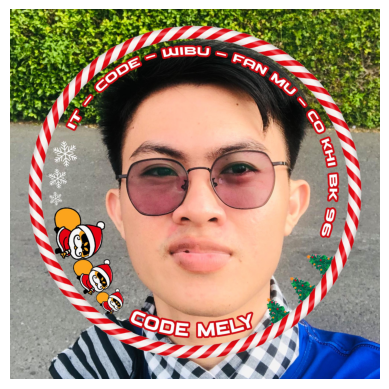

In [41]:
img = cv2.imread('avtgit.jpg')
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img), plt.axis('off')    

### **2.1 Image filtering**

#### **2.1.1 Convolution**

In [45]:
list_kernel_size = np.array([3, 5, 7])
list_kernel = [np.ones((i, i), np.float32)/(i*i) for i in list_kernel_size]
list_kernel[0]

array([[0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111],
       [0.11111111, 0.11111111, 0.11111111]])

In [46]:
def apply_kernel(img, kernel):
    return cv2.filter2D(img, -1, kernel,(-1,  -1),  delta=0,  borderType  = cv2.BORDER_DEFAULT)

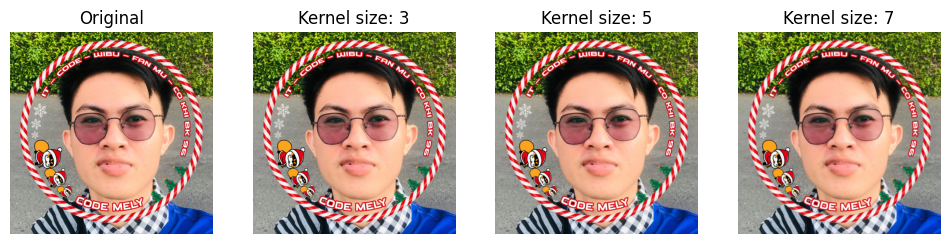

In [47]:
plt.figure(figsize=(12, 10))
plt.subplot(1,4,1), plt.imshow(img), plt.axis('off'), plt.title('Original')
for i, kernel in enumerate(list_kernel):
    img_filtered = apply_kernel(img, kernel)
    plt.subplot(1, 4, i+2)
    plt.imshow(img_filtered), plt.axis('off')
    plt.title('Kernel size: %d' % list_kernel_size[i])

**• Ex. 2.1 Thay đổi kernel được sử dụng trong ví dụ trước và phân tích kết quả. Hãy thử sử dụng kernel
mà không chuẩn hóa các giá trị theo số phần tử trong kernel. Điều này làm thay đổi đầu ra như thế nào
mức độ sáng của hình ảnh so với hình ảnh đầu vào?**

(<Axes: title={'center': 'Not normalized kernel'}>,
 (np.float64(-0.5), np.float64(1999.5), np.float64(1999.5), np.float64(-0.5)),
 Text(0.5, 1.0, 'Not normalized kernel'))

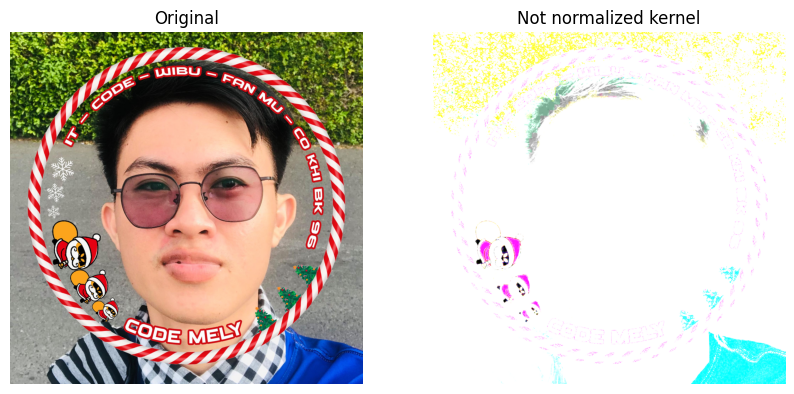

In [50]:
kernel_not_normalized = np.ones((5, 5), np.float32)
img_not_normalized = apply_kernel(img, kernel_not_normalized)
plt.figure(figsize=(10, 6))
plt.subplot(1, 2, 1), plt.imshow(img), plt.axis('off'), plt.title('Original')
plt.subplot(1, 2, 2), plt.imshow(img_not_normalized), plt.axis('off'), plt.title('Not normalized kernel')

=> Thay đổi kernel bằng cách loại bỏ bước chuẩn hóa các giá trị theo số phần tử trong kernel. Điều này sẽ làm thay đổi độ sáng của hình ảnh đầu ra. Cụ thể, nếu không chia các phần tử trong kernel cho tổng số phần tử trong kernel, mỗi điểm ảnh trong kết quả sẽ trở thành tổng của các điểm ảnh trong vùng lân cận, thay vì trung bình của chúng, dẫn đến hình ảnh có thể bị quá sáng hoặc quá tối.

**• Ex. 2.2 Sửa đổi ví dụ trước bằng cách kiểm tra các kernel sau trên ảnh đầu vào
“white_square.jpg” và “hop.jpg”**

In [52]:
# Danh sách các kernel cần thử nghiệm
kernels = {
    "h1": np.array([[0, 0, 0],
                    [0, 1, 0],
                    [0, 0, 0]], dtype=np.float32),

    "h2": np.array([[0, 0, 0],
                    [0, 0, 0],
                    [0, 0, 1]], dtype=np.float32),

    "h3": np.array([[-1, -1, -1],
                    [-1,  8, -1],
                    [-1, -1, -1]], dtype=np.float32),

    "h4": (1/16) * np.array([[1, 2, 1],
                             [2, 4, 2],
                             [1, 2, 1]], dtype=np.float32)
}


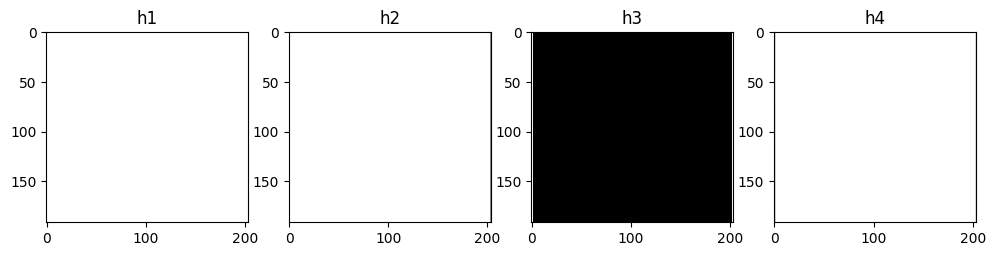

In [55]:
white_square = cv2.imread('white_square.png')
plt.figure(figsize=(12, 6))
for kernel_name, kernel in kernels.items():
    img_filtered = apply_kernel(white_square, kernel)
    plt.subplot(1, 4, list(kernels.keys()).index(kernel_name)+1)
    plt.imshow(img_filtered, cmap='gray')
    plt.title(kernel_name)

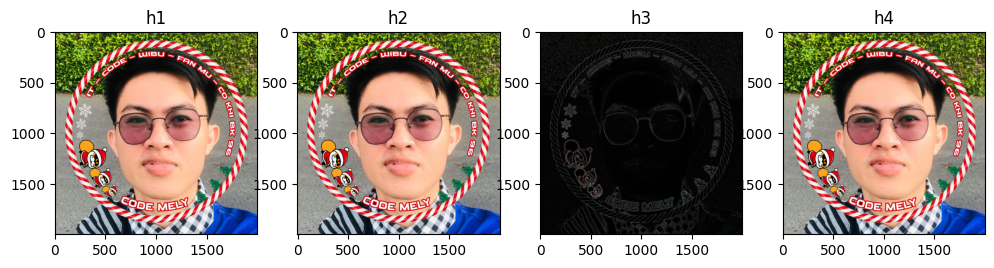

In [57]:
hop_image = img.copy()
plt.figure(figsize=(12, 10))
for kernel_name, kernel in kernels.items():
    img_filtered = apply_kernel(hop_image, kernel)
    plt.subplot(1, 4, list(kernels.keys()).index(kernel_name)+1)
    plt.imshow(img_filtered)
    plt.title(kernel_name)

#### **2.1.2 Box blur**

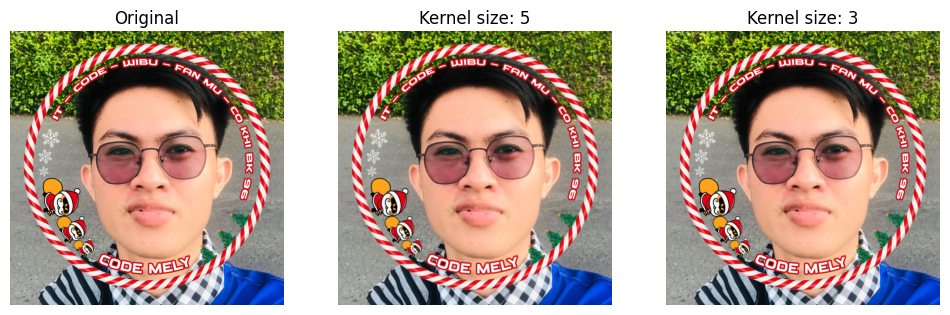

In [60]:
dst1 = cv2.blur(img, (5, 5), (-1, -1))
dst2 = cv2.blur(img, (3, 3), (-1, -1))
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1), plt.imshow(img), plt.axis('off'), plt.title('Original')
plt.subplot(1, 3, 2), plt.imshow(dst1), plt.axis('off'), plt.title('Kernel size: 5')
plt.subplot(1, 3, 3), plt.imshow(dst2), plt.axis('off'), plt.title('Kernel size: 3')
plt.show()

#### **2.1.3 Gaussian filtering in OpenCV**

Kernel hộp (Box kernel) được giải thích trước đó cân bằng đóng góp của tất cả các điểm ảnh trong vùng lân cận một cách đều nhau. Ngược lại, kernel làm mờ Gaussian (Gaussian Blur kernel) cân bằng đóng góp của các điểm ảnh lân cận dựa trên khoảng cách của điểm ảnh đó đến điểm ảnh trung tâm. Hình dạng của đường cong được điều khiển bởi một tham số duy nhất gọi là σ, tham số này điều chỉnh mức độ nhọn của đặc tính hình đồi:

$$
G(x, y) = \frac{1}{2\pi\sigma^2} e^{-\frac{x^2 + y^2}{2\sigma^2}}
$$

Giá trị σ lớn hơn sẽ tạo ra một kernel làm mờ mạnh hơn. Một kernel Gaussian kích thước 5x5 với σ = 1 được cho bởi:

$$
\frac{1}{337}
\begin{bmatrix}
1 & 4 & 7 & 4 & 1 \\
4 & 20 & 33 & 20 & 4 \\
7 & 33 & 55 & 33 & 7 \\
4 & 20 & 33 & 20 & 4 \\
1 & 4 & 7 & 4 & 1
\end{bmatrix}
$$

Rõ ràng là điểm ảnh ở giữa có trọng số lớn nhất, trong khi các điểm ảnh càng xa thì trọng số càng nhỏ.


Một hình ảnh được làm mờ bằng kernel Gaussian sẽ trông ít bị mờ hơn so với khi sử dụng kernel hộp có cùng kích thước. Một lượng nhỏ làm mờ Gaussian thường được sử dụng để loại bỏ nhiễu khỏi hình ảnh. Nó cũng được áp dụng cho hình ảnh trước khi thực hiện các thao tác lọc ảnh nhạy cảm với nhiễu. Ví dụ, kernel Sobel được sử dụng để tính đạo hàm của ảnh là sự kết hợp giữa kernel Gaussian và kernel sai phân hữu hạn.

Hàm trong OpenCV thực hiện việc lọc Gaussian là `GaussianBlur` với cú pháp như sau:

```python
dst = cv2.GaussianBlur(src, ksize, sigmaX[, dst[, sigmaY[, borderType]]])
```

---

**• Ex. 2.4 Thêm các dòng mã còn thiếu, được biểu thị bằng nhận xét. Mô tả cả việc làm mịn
hoạt động so sánh các hình ảnh cuối cùng: nền logo xuất hiện mượt mà hơn bao nhiêu? thế nào rồi
đường viền trong hình ảnh thay đổi với hạt nhân mờ? Hãy thử lọc Gaussian cho hình ảnh thử nghiệm
“logo_noise2.jpg” và “lina_noise.jpg” và xác định kích thước kernel tốt nhất.**

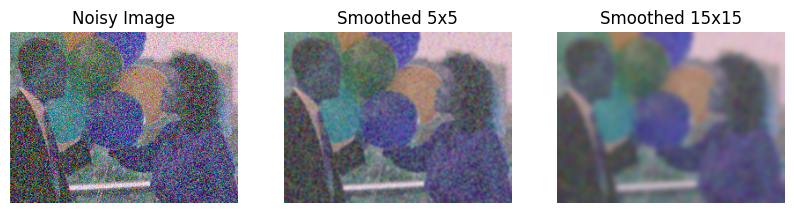

In [62]:
noise_img = cv2.imread('noise_image.png')
noise_img = cv2.cvtColor(noise_img, cv2.COLOR_BGR2RGB)

dst1 = cv2.GaussianBlur(noise_img,(5,5),sigmaX = 0,sigmaY = 0)
dst2 = cv2.GaussianBlur(noise_img,(15,15),sigmaX = 3,sigmaY = 3)

plt.figure(figsize=(10, 10))
plt.subplot(131);plt.imshow(noise_img[...,::-1]);plt.title("Noisy Image"), plt.axis('off')
plt.subplot(132);plt.imshow(dst1[...,::-1]);plt.title("Smoothed 5x5"), plt.axis('off')
plt.subplot(133);plt.imshow(dst2[...,::-1]);plt.title("Smoothed 15x15"), plt.axis('off')
plt.show()

### **2.1.4 Median filter**

Lọc trung vị (Median blur filtering) là một kỹ thuật lọc phi tuyến, chủ yếu được sử dụng để loại bỏ nhiễu muối tiêu (salt-and-pepper noise) khỏi hình ảnh. Trong các ảnh màu, nhiễu muối tiêu có thể xuất hiện dưới dạng các đốm màu ngẫu nhiên nhỏ. Bộ lọc trung vị trong OpenCV nên có kernel hình vuông với chiều dài cạnh là một số lẻ. Bộ lọc làm mờ trung vị thay thế giá trị của điểm ảnh trung tâm bằng giá trị trung vị của tất cả các điểm ảnh trong vùng kernel. Giá trị trung vị được tính bằng cách sắp xếp các điểm ảnh theo thứ tự tăng dần và chọn giá trị ở giữa làm ước lượng.

Hãy xem xét một vùng 3x3 từ một hình ảnh bị nhiễu muối tiêu:

$$
\begin{bmatrix}
60 & 62 & 59 \\
61 & 255 & 65 \\
65 & 60 & 63
\end{bmatrix}
$$

Dễ dàng nhận thấy rằng giá trị tại điểm ảnh trung tâm cao hơn rất nhiều so với các điểm ảnh xung quanh, nên có khả năng bị ảnh hưởng bởi nhiễu. Nếu chúng ta sử dụng bộ lọc làm mờ hộp (Box Blur) để làm mịn nhiễu này, giá trị của điểm ảnh trung tâm sau khi lọc sẽ là:

$$
\frac{60 + 62 + 59 + 61 + 255 + 65 + 65 + 60 + 63}{9} = 83.3
$$

do đó vùng ảnh sau khi lọc hộp sẽ là:

$$
\begin{bmatrix}
60 & 62 & 59 \\
61 & 83 & 65 \\
65 & 60 & 63
\end{bmatrix}
$$

Kết quả đã được cải thiện rõ ràng, nhưng giá trị trung tâm vẫn cao hơn so với các điểm ảnh xung quanh. Sử dụng bộ lọc trung vị, các điểm ảnh được sắp xếp sẽ là:

$$
[59, 60, 60, 61, \mathbf{62}, 63, 65, 65, 255]
$$

và giá trị ở giữa danh sách sắp xếp là 62. Vì vậy, sau khi lọc điểm ảnh trung tâm, vùng ảnh sẽ trở thành:

$$
\begin{bmatrix}
60 & 62 & 59 \\
61 & 62 & 65 \\
65 & 60 & 63
\end{bmatrix}
$$

Quy trình này được lặp lại theo cùng một cách cho tất cả các điểm ảnh trong ảnh đầu vào.

---

**• Ex2.5 Thêm các dòng mã còn thiếu, được biểu thị bằng nhận xét. Loại kết cấu nào bị ảnh hưởng
nhất bởi tiếng ồn muối tiêu? Bộ lọc làm mịn nào hoạt động tốt hơn trên các cạnh? theo thứ tự
để bảo toàn các cạnh, nên sử dụng kernel lớn hơn hay kernel nhỏ hơn? Cái nào loại bỏ tiếng ồn nhất
một cách hiệu quả? Hãy thử trải nghiệm với các kích thước hạt nhân khác!**

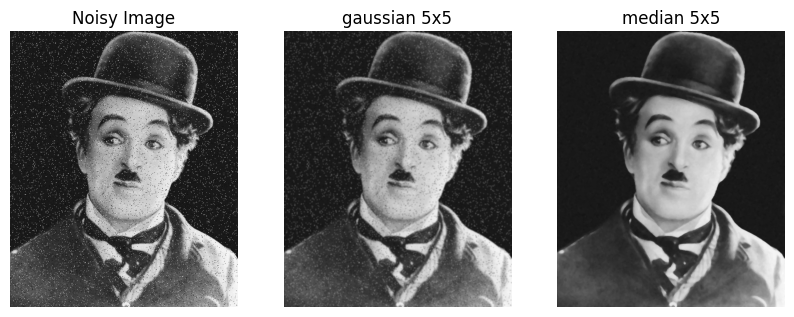

In [64]:
noise_img_2 = cv2.imread('noise_image2.png') 
kernelSize = 5
dst1 =  cv2.GaussianBlur(noise_img_2, (kernelSize, kernelSize), sigmaX = 0, sigmaY = 0)
dst2 = cv2.medianBlur(noise_img_2 , kernelSize)

plt.figure(figsize = (10, 10))
plt.subplot(131);plt.imshow(noise_img_2[...,::-1]);plt.title("Noisy Image"), plt.axis('off')
plt.subplot(132);plt.imshow(dst1[...,::-1]);plt.title("gaussian 5x5"), plt.axis('off')
plt.subplot(133);plt.imshow(dst2[...,::-1]);plt.title("median 5x5"), plt.axis('off')
plt.show()

### **2.3 Image sharpening**

**Bước 1: Đọc ảnh đầu vào**

In [65]:
image = cv2.imread('avtgit.jpg')
if image is None:
    print("Could not open the image")

**Bước 2: Làm mờ ảnh đầu vào bằng bộ lọc Gaussian**

In [66]:
blurred_image = cv2.GaussianBlur(image, (5, 5), 0)  # Làm mờ ảnh với kernel 5x5

**Bước 3: Tính thông tin tần số cao bằng cách trừ ảnh đã làm mờ khỏi ảnh gốc**

In [67]:
high_freq_details = image - blurred_image

**Bước 4: Điều chỉnh lượng thông tin tần số cao và thêm vào ảnh gốc**

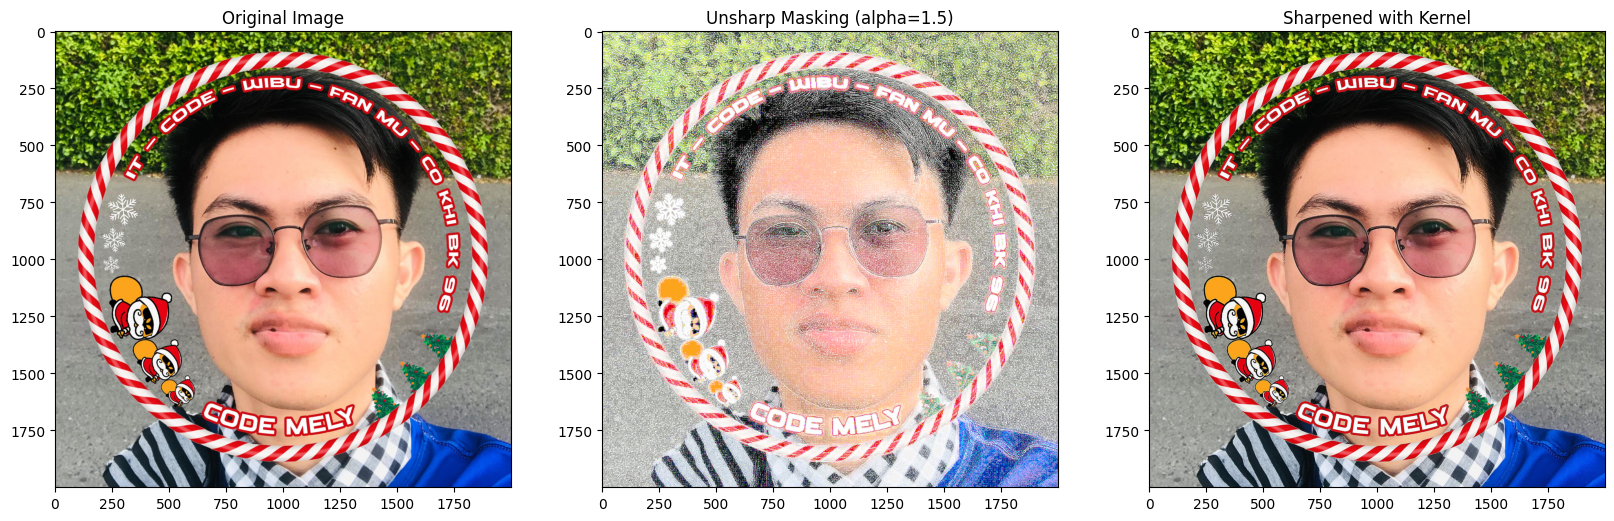

In [69]:
alpha = 1.5  # Hệ số điều chỉnh
sharpened_image = cv2.addWeighted(image, 1.0, high_freq_details, alpha, 0)

# Hoặc sử dụng kernel làm sắc nét để làm sắc nét trực tiếp
# Kernel làm sắc nét với alpha = 1
sharpening_kernel = np.array([[ 0, -1,  0],
                              [-1,  5, -1],
                              [ 0, -1,  0]], dtype=np.float32)

# Áp dụng kernel làm sắc nét lên ảnh gốc
sharpened_image_with_kernel = cv2.filter2D(image, -1, sharpening_kernel)

# Hiển thị kết quả
plt.figure(figsize=(20, 10))

plt.subplot(131); plt.imshow(image[..., ::-1]); plt.title("Original Image")
plt.subplot(132); plt.imshow(sharpened_image[..., ::-1]); plt.title("Unsharp Masking (alpha=1.5)")
plt.subplot(133); plt.imshow(sharpened_image_with_kernel[..., ::-1]); plt.title("Sharpened with Kernel")

plt.show()


**Sử dụng thư viện**

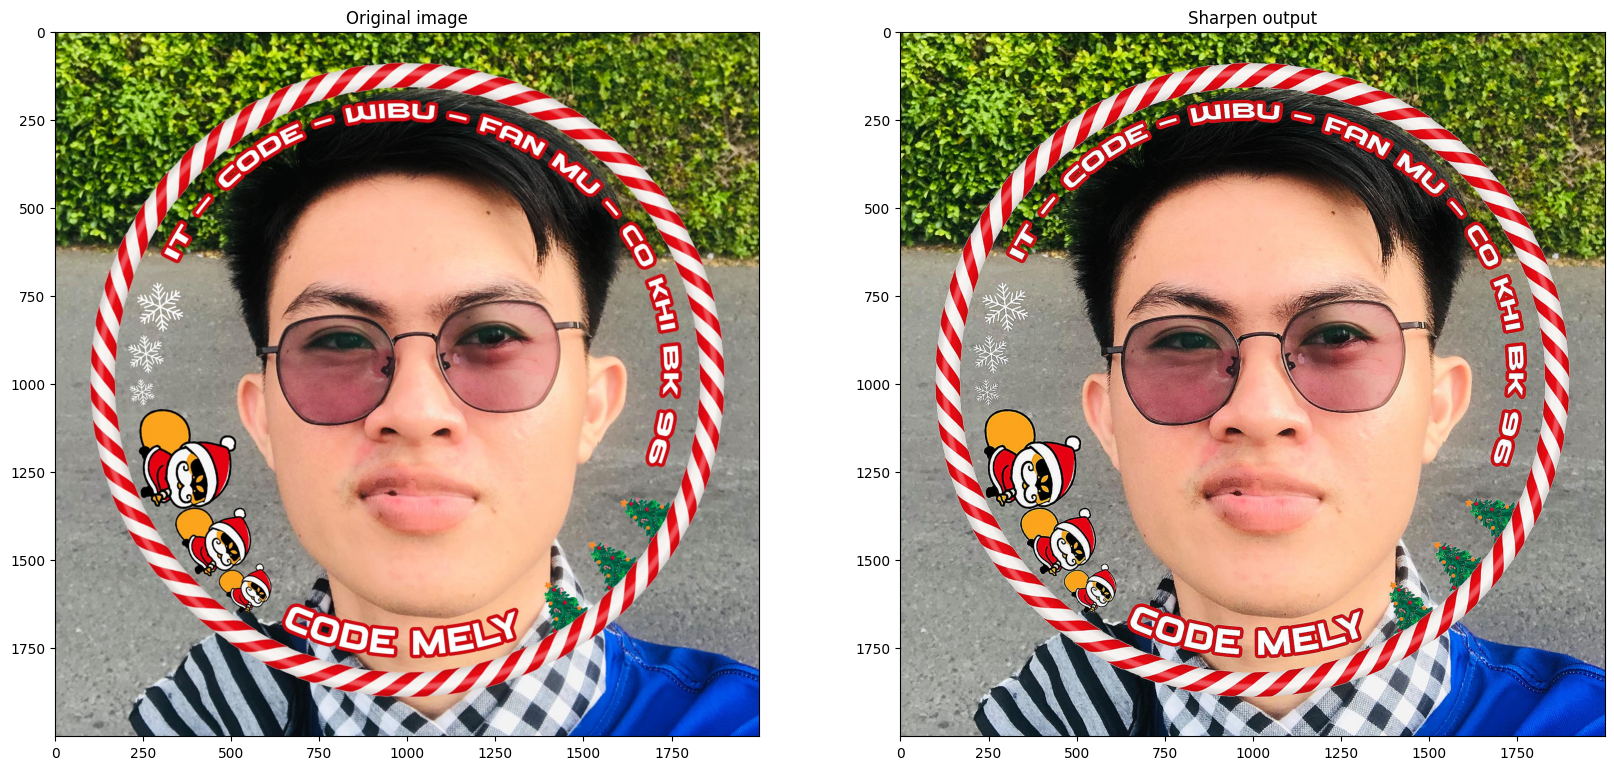

In [71]:
sharpen = np.array(( [0, -1, 0],
 [-1, 5, -1],
 [0, -1, 0]), dtype="int")
sharpImg = cv2.filter2D(image, -1, sharpen)
plt.figure(figsize=[20,10])
plt.subplot(121);plt.imshow(image[...,::-1]);plt.title("Original image")
plt.subplot(122);plt.imshow(sharpImg[...,::-1]);plt.title("Sharpen output")
plt.show()

**• Ex.2.9 Các thành phần kết cấu được làm nổi bật bởi hiệu ứng làm sắc nét là gì? Thử nghiệm cũng
với các hình ảnh khác (parrots.jpg). Mô tả loại kết cấu nổi bật hơn sau khi làm sắc nét
lọc.**

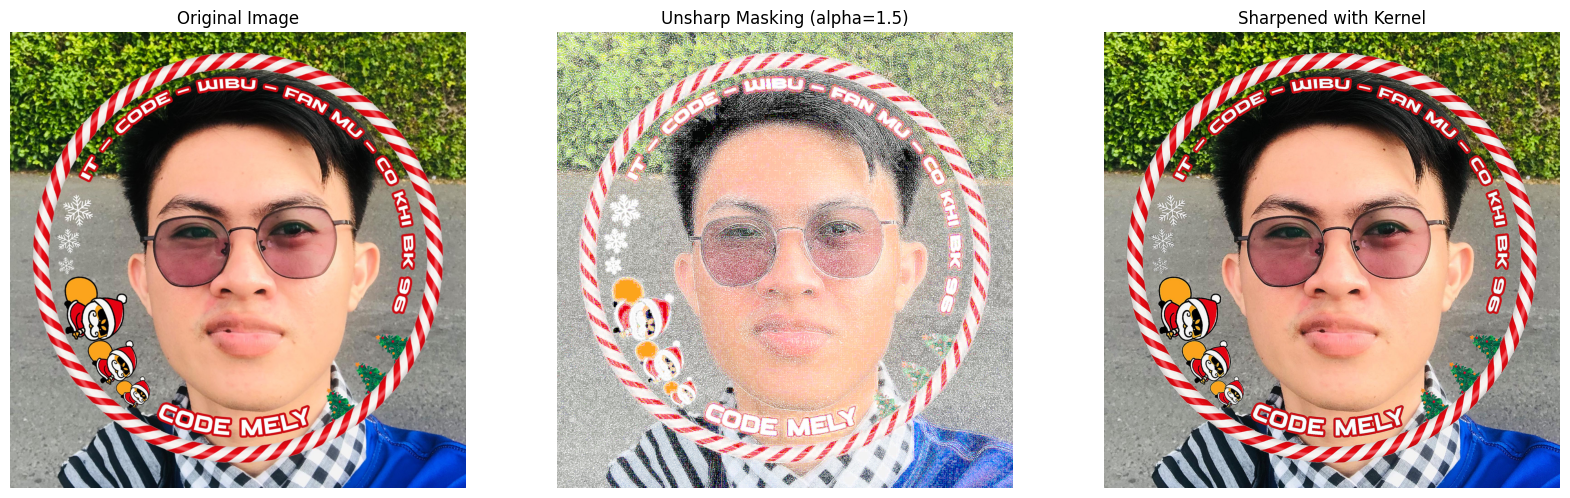

In [75]:
blurred_image = cv2.GaussianBlur(image, (5, 5), 0)

high_freq_details = image - blurred_image


alpha = 1.5
sharpened_image = cv2.addWeighted(image, 1.0, high_freq_details, alpha, 0)

# Kernel làm sắc nét
sharpening_kernel = np.array([[ 0, -1,  0],
                                [-1,  5, -1],
                                [ 0, -1,  0]], dtype=np.float32)

# Áp dụng kernel làm sắc nét lên ảnh gốc
sharpened_image_with_kernel = cv2.filter2D(image, -1, sharpening_kernel)

# Hiển thị kết quả
plt.figure(figsize=(20, 10))

plt.subplot(131); plt.imshow(image[...,::-1],cmap='gray'); plt.title("Original Image"), plt.axis('off')
plt.subplot(132); plt.imshow(sharpened_image[...,::-1],cmap='gray'); plt.title("Unsharp Masking (alpha=1.5)"), plt.axis('off')
plt.subplot(133); plt.imshow(sharpened_image_with_kernel[...,::-1],cmap='gray'); plt.title("Sharpened with Kernel"), plt.axis('off')

plt.show()